# 03 — Final Model Evaluation & Saving

**Project:** Business Data Analysis and Revenue Prediction Platform  
**Purpose:** Final evaluation on the isolated test set, then save all model artifacts.

---

> **Important:** The test set has been isolated since Phase 4.  
> This notebook is the **only place** where the test set is used.  
> No model decisions are made after this point.

## Notebook Structure

1. Setup & Full Pipeline Rebuild
2. Final Evaluation on Test Set
3. Validation vs Test Comparison
4. Actual vs Predicted Visualization
5. Residual Analysis
6. Feature Coefficient Analysis
7. Save Model Artifacts
8. Verify Saved Model
9. Evaluation Summary

## 1. Setup & Full Pipeline Rebuild

We rebuild the entire pipeline from scratch in this notebook to ensure
the saved model is trained on exactly the same data and preprocessing
as validated in Phase 4/5. This is the canonical, final training run.

In [1]:
import os
import json
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

RANDOM_STATE = 42

FEATURE_COLUMNS = [
    'marketing_spend',
    'advertising_spend',
    'website_traffic',
    'number_of_customers',
    'product_price',
    'discount_percentage',
    'previous_revenue',
]
TARGET_COLUMN = 'revenue'

MODEL_DIR    = '../models'
EVAL_VIZ_DIR = '../results/visualizations/model_evaluation'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(EVAL_VIZ_DIR, exist_ok=True)

# ── Load the cleaned processed dataset ───────────────────────────────────────
df = pd.read_csv('../data/processed/business_revenue_processed.csv')
print(f'Processed dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

Processed dataset loaded: 5,000 rows x 8 columns


In [2]:
# ── Reproduce the exact same split as Phase 4 ─────────────────────────────────
# Using the same RANDOM_STATE=42 guarantees identical splits every time.
X = df[FEATURE_COLUMNS]
y = df[TARGET_COLUMN]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

# ── Fit scaler on training data only ─────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)   # Unlocked for first time

# ── Train final model ─────────────────────────────────────────────────────────
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print('Pipeline rebuilt successfully.')
print(f'  Train : {len(X_train):,} samples')
print(f'  Val   : {len(X_val):,} samples')
print(f'  Test  : {len(X_test):,} samples  <-- being used for the first time now')

Pipeline rebuilt successfully.
  Train : 3,500 samples
  Val   : 750 samples
  Test  : 750 samples  <-- being used for the first time now


## 2. Final Evaluation on Test Set

This is the moment the test set is used for the first and **only** time.
The result is the honest, final performance estimate of the model.

In [3]:
def compute_metrics(y_true, y_pred):
    """Return a dict of regression metrics."""
    mae  = float(mean_absolute_error(y_true, y_pred))
    mse  = float(mean_squared_error(y_true, y_pred))
    rmse = float(np.sqrt(mse))
    r2   = float(r2_score(y_true, y_pred))
    return {'mae': mae, 'mse': mse, 'rmse': rmse, 'r2': r2}

# Predictions on all three splits
y_pred_train = model.predict(X_train_scaled)
y_pred_val   = model.predict(X_val_scaled)
y_pred_test  = model.predict(X_test_scaled)

train_metrics = compute_metrics(y_train, y_pred_train)
val_metrics   = compute_metrics(y_val,   y_pred_val)
test_metrics  = compute_metrics(y_test,  y_pred_test)

def print_metrics(metrics_dict, label):
    print(f'{label}:')
    print(f'  MAE  : {metrics_dict["mae"]:>12,.2f}')
    print(f'  MSE  : {metrics_dict["mse"]:>12,.2f}')
    print(f'  RMSE : {metrics_dict["rmse"]:>12,.2f}')
    print(f'  R2   : {metrics_dict["r2"]:>12.4f}')

print('=' * 48)
print_metrics(train_metrics, 'Train     ')
print()
print_metrics(val_metrics,   'Validation')
print()
print_metrics(test_metrics,  'Test      ')
print('=' * 48)

Train     :
  MAE  :    13,751.11
  MSE  : 283,080,161.25
  RMSE :    16,824.99
  R2   :       0.8921

Validation:
  MAE  :    14,127.90
  MSE  : 299,508,040.77
  RMSE :    17,306.30
  R2   :       0.8877

Test      :
  MAE  :    14,127.04
  MSE  : 295,075,947.15
  RMSE :    17,177.77
  R2   :       0.8847


## 3. Validation vs Test Comparison

Comparing validation and test metrics tells us whether the model generalises well:

- If **test metrics ≈ validation metrics** → good generalisation, no overfitting to the validation set
- If **test metrics are significantly worse** → possible overfitting or distribution shift
- If **test metrics are significantly better** → unlikely, may indicate a lucky test split

In [4]:
print('Validation vs Test Comparison:')
print(f'{"Metric":<8} {"Train":>12} {"Validation":>12} {"Test":>12} {"Val-Test Gap":>14}')
print('-' * 60)

for key, label in [("mae","MAE"),("rmse","RMSE"),("r2","R2")]:
    tv = train_metrics[key]
    vv = val_metrics[key]
    tev = test_metrics[key]
    gap = abs(vv - tev)
    print(f'{label:<8} {tv:>12.2f} {vv:>12.2f} {tev:>12.2f} {gap:>14.4f}')

print()
r2_gap = abs(val_metrics['r2'] - test_metrics['r2'])
if r2_gap < 0.01:
    status = 'Excellent generalisation (R2 gap < 0.01)'
elif r2_gap < 0.03:
    status = 'Good generalisation (R2 gap < 0.03)'
elif r2_gap < 0.05:
    status = 'Acceptable generalisation'
else:
    status = 'Notable gap -- review model'
print(f'Generalisation status: {status}')

Validation vs Test Comparison:
Metric          Train   Validation         Test   Val-Test Gap
------------------------------------------------------------
MAE          13751.11     14127.90     14127.04         0.8646
RMSE         16824.99     17306.30     17177.77       128.5258
R2               0.89         0.89         0.88         0.0030

Generalisation status: Excellent generalisation (R2 gap < 0.01)


## 4. Actual vs Predicted Visualization

The **Actual vs Predicted plot** is the most informative single visualisation for a regression model.

**How to read it:**
- The dashed diagonal line represents **perfect predictions** (predicted = actual)
- Points **on the line** are perfect predictions
- Points **above the line** mean the model over-predicted revenue
- Points **below the line** mean the model under-predicted revenue
- The **tighter the cluster around the diagonal**, the better the model

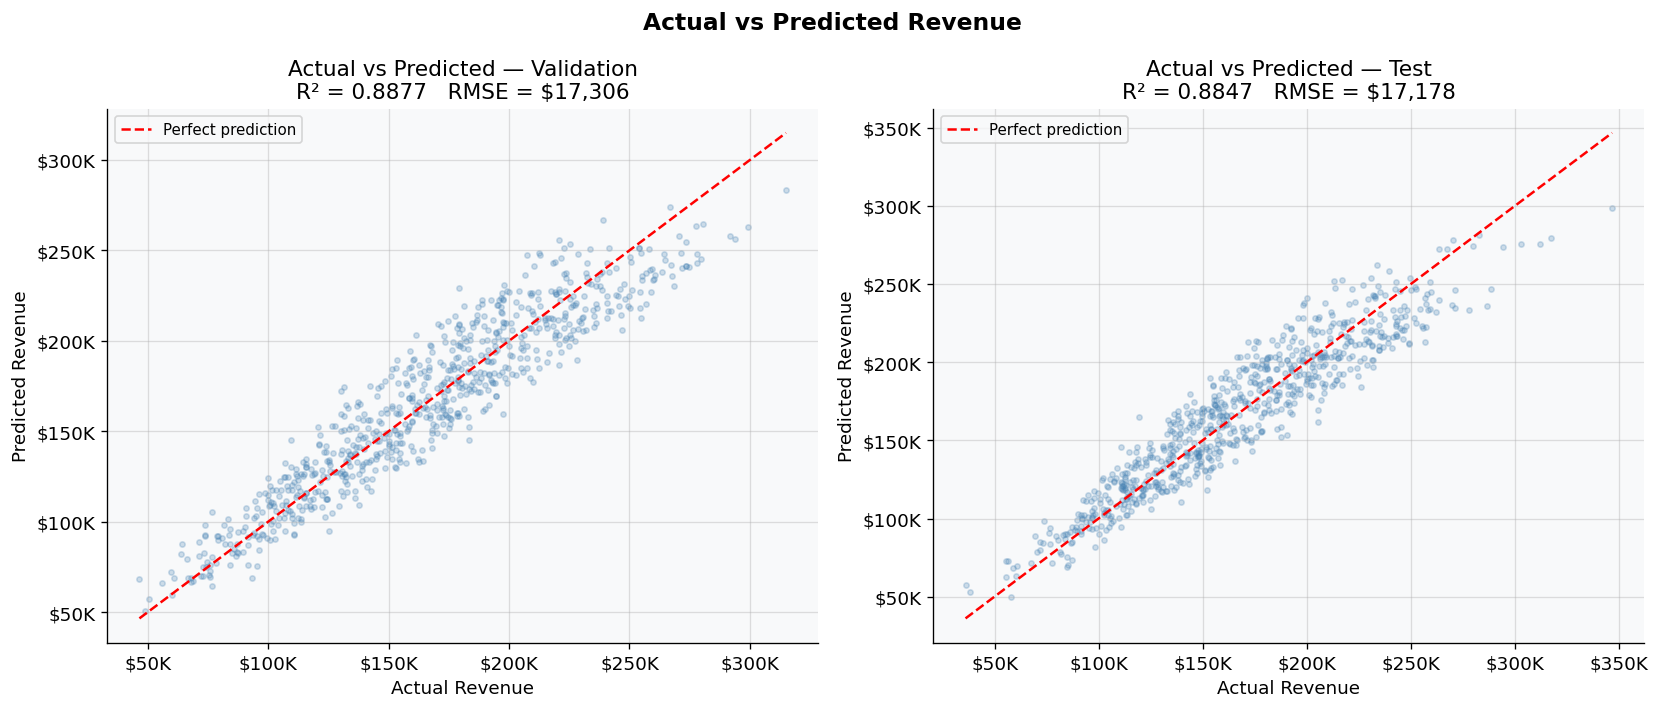

Saved: ../results/visualizations/model_evaluation\actual_vs_predicted.png


In [5]:
def fmt_k(x, _):
    if abs(x) >= 1_000:
        return f'${x/1000:.0f}K'
    return f'${x:.0f}'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_true, y_pred, split_label, metrics_d in [
    (axes[0], y_val,  y_pred_val,  'Validation', val_metrics),
    (axes[1], y_test, y_pred_test, 'Test',        test_metrics),
]:
    ax.scatter(y_true, y_pred, alpha=0.25, s=10, color='steelblue')

    lo = min(float(y_true.min()), float(y_pred.min()))
    hi = max(float(y_true.max()), float(y_pred.max()))
    ax.plot([lo, hi], [lo, hi], color='red', linewidth=1.5,
            linestyle='--', label='Perfect prediction')

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
    ax.set_xlabel('Actual Revenue')
    ax.set_ylabel('Predicted Revenue')
    ax.set_title(
        f'Actual vs Predicted — {split_label}\n'
        f'R\u00b2 = {metrics_d["r2"]:.4f}   RMSE = ${metrics_d["rmse"]:,.0f}'
    )
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted Revenue', fontsize=14, fontweight='bold')
plt.tight_layout()
path = os.path.join(EVAL_VIZ_DIR, 'actual_vs_predicted.png')
plt.savefig(path, bbox_inches='tight', dpi=120)
plt.show()
print(f'Saved: {path}')

## 5. Residual Analysis

**Residuals** = Actual Revenue − Predicted Revenue

For a well-specified Linear Regression model, residuals should be:
- **Randomly scattered around zero** — no systematic pattern
- **Roughly constant in spread** — no funnel shape (homoscedasticity)
- **Approximately normally distributed**

Patterns in residuals indicate the model is missing something — a non-linear
relationship, an interaction between features, or a missing variable.

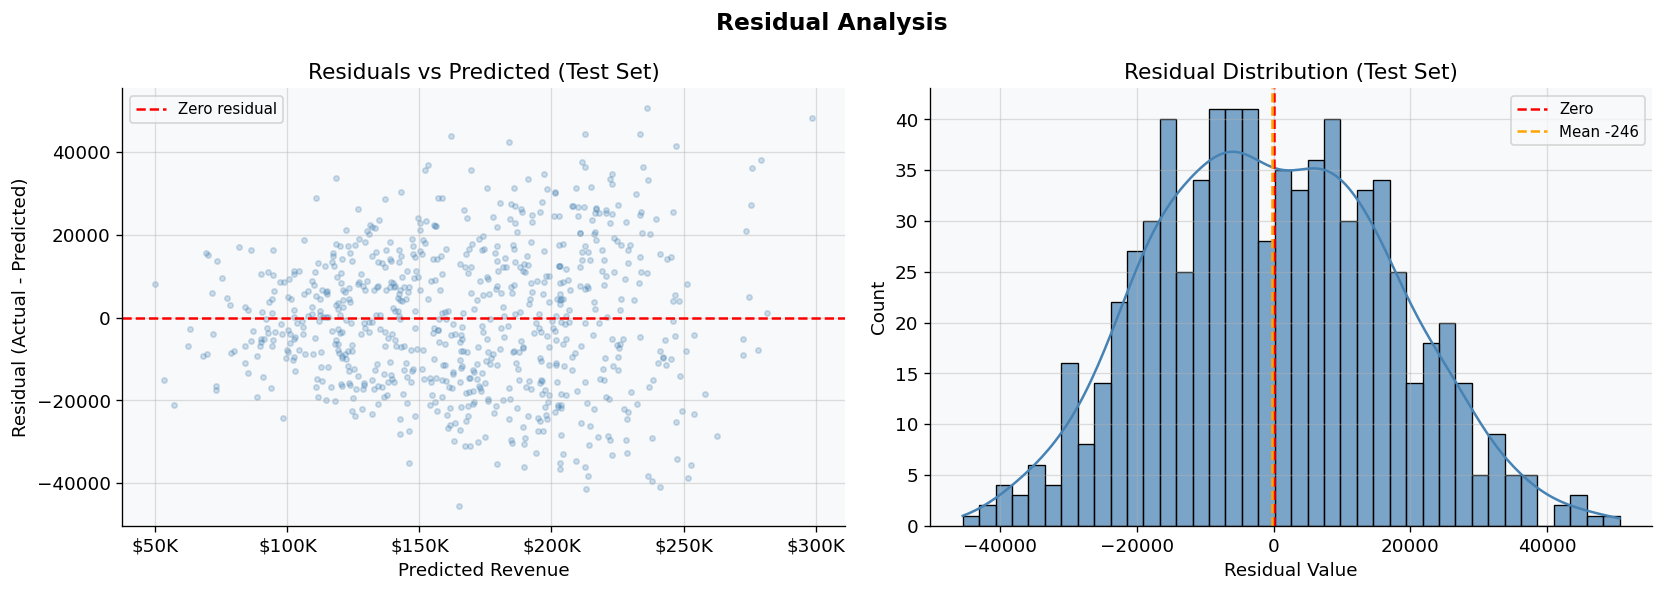

Saved: ../results/visualizations/model_evaluation\residual_analysis.png

Residual mean :    -246.41  (should be near 0)
Residual std  :  17,176.01
Residual min  : -45,463.11
Residual max  :  50,595.56


In [6]:
residuals_test = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Residuals vs Predicted
ax1 = axes[0]
ax1.scatter(y_pred_test, residuals_test, alpha=0.25, s=10, color='steelblue')
ax1.axhline(0, color='red', linewidth=1.5, linestyle='--', label='Zero residual')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax1.set_xlabel('Predicted Revenue')
ax1.set_ylabel('Residual (Actual - Predicted)')
ax1.set_title('Residuals vs Predicted (Test Set)')
ax1.legend(fontsize=9)

# Right: Residual distribution
ax2 = axes[1]
sns.histplot(residuals_test, bins=40, kde=True, ax=ax2, color='steelblue', alpha=0.7)
ax2.axvline(0,                         color='red',    linewidth=1.5, linestyle='--', label='Zero')
ax2.axvline(residuals_test.mean(),      color='orange', linewidth=1.5, linestyle='--',
            label=f'Mean {residuals_test.mean():,.0f}')
ax2.set_xlabel('Residual Value')
ax2.set_ylabel('Count')
ax2.set_title('Residual Distribution (Test Set)')
ax2.legend(fontsize=9)

plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
path = os.path.join(EVAL_VIZ_DIR, 'residual_analysis.png')
plt.savefig(path, bbox_inches='tight', dpi=120)
plt.show()
print(f'Saved: {path}')
print()
print(f'Residual mean : {residuals_test.mean():>10,.2f}  (should be near 0)')
print(f'Residual std  : {residuals_test.std():>10,.2f}')
print(f'Residual min  : {residuals_test.min():>10,.2f}')
print(f'Residual max  : {residuals_test.max():>10,.2f}')

## 6. Feature Coefficient Analysis

Linear Regression coefficients tell us how much the predicted revenue changes
when a feature increases by **one standard deviation** (since the features are scaled).

**Interpretation on scaled features:**
- A coefficient of +41,000 for `previous_revenue` means: a one standard deviation
  increase in previous revenue is associated with a ~$41,000 increase in predicted revenue.
- This is the fairest comparison across features because all features are now on the same scale.

**Important caveats:**
1. Coefficients reflect **linear associations** — they do not prove causation.
2. Correlated features share explained variance, so individual coefficients
   can be misleading when features are correlated with each other.
3. These are not the same as feature importances from tree-based models.

Model Coefficients (on StandardScaled features):
Feature                      Coefficient  Direction
--------------------------------------------------
discount_percentage            -2,942.84  Negative (-)
website_traffic                 1,867.78  Positive (+)
product_price                   2,148.70  Positive (+)
advertising_spend               4,590.92  Positive (+)
marketing_spend                10,999.16  Positive (+)
number_of_customers            17,576.15  Positive (+)
previous_revenue               41,567.98  Positive (+)
  intercept                   165,242.36


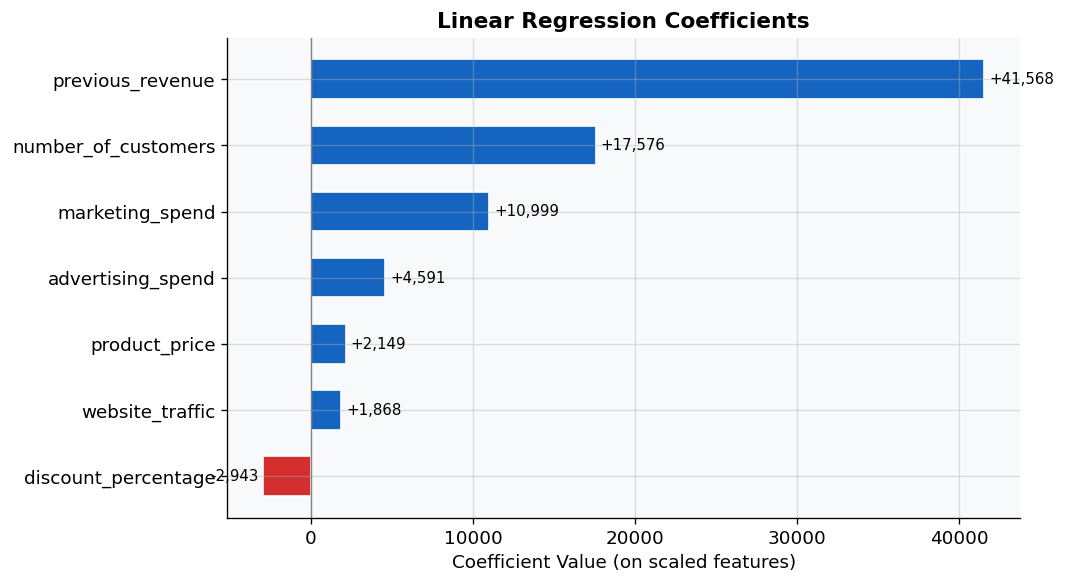

Saved: ../results/visualizations/model_evaluation\feature_coefficients.png


In [7]:
coef_df = pd.DataFrame({
    'feature':     FEATURE_COLUMNS,
    'coefficient': model.coef_
}).sort_values('coefficient')

print('Model Coefficients (on StandardScaled features):')
print(f'{"Feature":<25} {"Coefficient":>14}  Direction')
print('-' * 50)
for _, row in coef_df.iterrows():
    direction = 'Positive (+)' if row['coefficient'] > 0 else 'Negative (-)'
    print(f"{row['feature']:<25} {row['coefficient']:>14,.2f}  {direction}")
print(f'  {"intercept":<23} {model.intercept_:>14,.2f}')

# Bar chart of coefficients
colors = ['#d32f2f' if v < 0 else '#1565c0' for v in coef_df['coefficient']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(coef_df['feature'], coef_df['coefficient'],
               color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, coef_df['coefficient']):
    xpos = val + 300 if val >= 0 else val - 300
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f'{val:+,.0f}', va='center', ha=ha, fontsize=9)

ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Coefficient Value (on scaled features)')
ax.set_title('Linear Regression Coefficients', fontsize=13, fontweight='bold')
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
path = os.path.join(EVAL_VIZ_DIR, 'feature_coefficients.png')
plt.savefig(path, bbox_inches='tight', dpi=120)
plt.show()
print(f'Saved: {path}')

## 7. Save Model Artifacts

We save three files to `models/`:

| File | Contents | Used by |
|---|---|---|
| `revenue_prediction_model.pkl` | Trained `LinearRegression` object | Backend prediction |
| `preprocessing.pkl` | Fitted `StandardScaler` object | Backend preprocessing |
| `model_metadata.json` | Metrics, features, version info | Backend `/model-info` endpoint + frontend |

We use `joblib` instead of Python's `pickle` because joblib is optimised for
NumPy arrays and scikit-learn objects — it is faster and produces smaller files.

In [8]:
model_path  = os.path.join(MODEL_DIR, 'revenue_prediction_model.pkl')
scaler_path = os.path.join(MODEL_DIR, 'preprocessing.pkl')
meta_path   = os.path.join(MODEL_DIR, 'model_metadata.json')

# Save model
joblib.dump(model, model_path)
print(f'Model saved   : {model_path}')

# Save scaler
joblib.dump(scaler, scaler_path)
print(f'Scaler saved  : {scaler_path}')

# Build and save metadata
metadata = {
    "model_name":    "Business Revenue Prediction Model",
    "model_type":    "Linear Regression",
    "target":        TARGET_COLUMN,
    "features":      FEATURE_COLUMNS,
    "feature_count": len(FEATURE_COLUMNS),
    "training_date": datetime.now().strftime('%Y-%m-%d'),
    "random_state":  RANDOM_STATE,
    "dataset": {
        "total_samples":      int(len(df)),
        "train_samples":      int(len(X_train)),
        "validation_samples": int(len(X_val)),
        "test_samples":       int(len(X_test)),
        "train_pct":          70,
        "validation_pct":     15,
        "test_pct":           15
    },
    "preprocessing": {
        "scaler":       "StandardScaler",
        "fit_on":       "training set only",
        "scaler_means": {col: round(float(m), 4) for col, m in zip(FEATURE_COLUMNS, scaler.mean_)},
        "scaler_stds":  {col: round(float(s), 4) for col, s in zip(FEATURE_COLUMNS, scaler.scale_)}
    },
    "validation_metrics": {
        "mae":  round(val_metrics['mae'],  2),
        "mse":  round(val_metrics['mse'],  2),
        "rmse": round(val_metrics['rmse'], 2),
        "r2":   round(val_metrics['r2'],   4)
    },
    "test_metrics": {
        "mae":  round(test_metrics['mae'],  2),
        "mse":  round(test_metrics['mse'],  2),
        "rmse": round(test_metrics['rmse'], 2),
        "r2":   round(test_metrics['r2'],   4)
    },
    "library_versions": {
        "scikit_learn": sklearn.__version__,
        "numpy":        np.__version__,
        "pandas":       pd.__version__,
        "joblib":       joblib.__version__
    },
    "coefficients": {
        col: round(float(coef), 4)
        for col, coef in zip(FEATURE_COLUMNS, model.coef_)
    },
    "intercept": round(float(model.intercept_), 4)
}

with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'Metadata saved: {meta_path}')
print()
print('All model artifacts saved to models/')

Model saved   : ../models\revenue_prediction_model.pkl
Scaler saved  : ../models\preprocessing.pkl
Metadata saved: ../models\model_metadata.json

All model artifacts saved to models/


## 8. Verify Saved Model

We immediately verify the saved model by loading it back and making a test prediction.
This confirms the files are not corrupted and the pipeline is reproducible end-to-end.

In [9]:
print('Verifying saved model...')
print()

# Load back from disk
loaded_model  = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)

with open(meta_path, 'r') as f:
    loaded_meta = json.load(f)

# Make a sample prediction using a manually constructed input
sample_input = pd.DataFrame([{
    'marketing_spend':     10000,
    'advertising_spend':   5000,
    'website_traffic':     50000,
    'number_of_customers': 1200,
    'product_price':       50,
    'discount_percentage': 10,
    'previous_revenue':    100000
}])

sample_scaled     = loaded_scaler.transform(sample_input[FEATURE_COLUMNS])
sample_prediction = loaded_model.predict(sample_scaled)[0]

print(f'Sample input:')
for col in FEATURE_COLUMNS:
    print(f'  {col:<25} : {sample_input[col].iloc[0]:,.2f}')
print()
print(f'Predicted Revenue : {sample_prediction:,.2f}')
print()
print('Model verification passed.')
print()
print('File sizes:')
for fpath in [model_path, scaler_path, meta_path]:
    size_kb = os.path.getsize(fpath) / 1024
    print(f'  {os.path.basename(fpath):<40} {size_kb:.1f} KB')

Verifying saved model...

Sample input:
  marketing_spend           : 10,000.00
  advertising_spend         : 5,000.00
  website_traffic           : 50,000.00
  number_of_customers       : 1,200.00
  product_price             : 50.00
  discount_percentage       : 10.00
  previous_revenue          : 100,000.00

Predicted Revenue : 80,664.86

Model verification passed.

File sizes:
  revenue_prediction_model.pkl             0.6 KB
  preprocessing.pkl                        1.2 KB
  model_metadata.json                      1.9 KB


## 9. Evaluation Summary

In [10]:
print('=' * 55)
print('  FINAL EVALUATION SUMMARY')
print('=' * 55)
print()
print('MODEL')
print(f'  Type        : {loaded_meta["model_type"]}')
print(f'  Features    : {loaded_meta["feature_count"]}')
print(f'  Scaling     : {loaded_meta["preprocessing"]["scaler"]}')
print(f'  Train date  : {loaded_meta["training_date"]}')
print()
print('DATASET SPLIT')
print(f'  Train       : {loaded_meta["dataset"]["train_samples"]:,} ({loaded_meta["dataset"]["train_pct"]}%)')
print(f'  Validation  : {loaded_meta["dataset"]["validation_samples"]:,} ({loaded_meta["dataset"]["validation_pct"]}%)')
print(f'  Test        : {loaded_meta["dataset"]["test_samples"]:,} ({loaded_meta["dataset"]["test_pct"]}%)')
print()
print(f'  {"Metric":<8} {"Validation":>12} {"Test":>12}')
print(f'  {"-"*8} {"-"*12} {"-"*12}')
vm = loaded_meta['validation_metrics']
tm = loaded_meta['test_metrics']
print(f'  {"MAE":<8} {vm["mae"]:>12,.2f} {tm["mae"]:>12,.2f}')
print(f'  {"RMSE":<8} {vm["rmse"]:>12,.2f} {tm["rmse"]:>12,.2f}')
print(f'  {"R2":<8} {vm["r2"]:>12.4f} {tm["r2"]:>12.4f}')
print()
gap = abs(vm['r2'] - tm['r2'])
print(f'R2 gap (val vs test) : {gap:.4f}')
print()
print('SAVED ARTIFACTS')
for fpath in [model_path, scaler_path, meta_path]:
    print(f'  {fpath}')
print()
print('SAVED VISUALIZATIONS')
for f in sorted(os.listdir(EVAL_VIZ_DIR)):
    if f.endswith('.png'):
        print(f'  {EVAL_VIZ_DIR}/{f}')
print()
print('NEXT STEP: Phase 7 -- FastAPI Backend')
print('=' * 55)

  FINAL EVALUATION SUMMARY

MODEL
  Type        : Linear Regression
  Features    : 7
  Scaling     : StandardScaler
  Train date  : 2026-09-14

DATASET SPLIT
  Train       : 3,500 (70%)
  Validation  : 750 (15%)
  Test        : 750 (15%)

  Metric     Validation         Test
  -------- ------------ ------------
  MAE         14,127.90    14,127.04
  RMSE        17,306.30    17,177.77
  R2             0.8877       0.8847

R2 gap (val vs test) : 0.0030

SAVED ARTIFACTS
  ../models\revenue_prediction_model.pkl
  ../models\preprocessing.pkl
  ../models\model_metadata.json

SAVED VISUALIZATIONS
  ../results/visualizations/model_evaluation/actual_vs_predicted.png
  ../results/visualizations/model_evaluation/feature_coefficients.png
  ../results/visualizations/model_evaluation/residual_analysis.png
  ../results/visualizations/model_evaluation/validation_performance.png

NEXT STEP: Phase 7 -- FastAPI Backend
